In [ ]:
# cell 1
# Install Required Libraries
!pip install -q datasets evaluate jiwer accelerate librosa soundfile torchaudio
!pip install -q "transformers==4.36.2" "peft==0.10.0"
!pip install -q kaggle torchcodec

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 54.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.8/126.8 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 105.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 199.1/199.1 kB 18.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 77.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sentence-transformers 5.1.2 requires transformers<5.0.0,>=4.41.0, but you have transformers 4.36.2 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 89.2 MB/s eta 0:00:00


In [ ]:
# cell 2
# download db
import os, zipfile, shutil
from pathlib import Path

# 1) Upload kaggle.json
from google.colab import files
print("👉 Upload your kaggle.json file from Kaggle (Account > API > Create New Token)")
uploaded = files.upload()

# Move it to ~/.kaggle
os.makedirs("/root/.kaggle", exist_ok=True)
for fname in uploaded:
    shutil.move(fname, "/root/.kaggle/kaggle.json")

os.chmod("/root/.kaggle/kaggle.json", 0o600)

# 2) Download the dataset from Kaggle
DATA_ROOT = Path("/content/data")
DATA_ROOT.mkdir(parents=True, exist_ok=True)

!kaggle datasets download -d mayarjao/arabic-tts -p /content/data

👉 Upload your kaggle.json file from Kaggle (Account > API > Create New Token)


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/mayarjao/arabic-tts
License(s): CC0-1.0
 99% 9.27G/9.33G [00:20<00:00, 457MB/s]
100% 9.33G/9.33G [00:20<00:00, 495MB/s]


In [ ]:
zip_path = DATA_ROOT / "arabic-tts.zip"
TARGET_DIR = DATA_ROOT / "arabic_tts"
TARGET_DIR.mkdir(exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall(TARGET_DIR)

print("Extracted to:", TARGET_DIR)

# Quick peek
!ls -R /content/data/arabic_tts | head -n 60

Extracted to: /content/data/arabic_tts
/content/data/arabic_tts:
arabic_tts

/content/data/arabic_tts/arabic_tts:
metadata.csv
metadata-wav.csv
wavs

/content/data/arabic_tts/arabic_tts/wavs:
common_voice_ar_19058307.wav
common_voice_ar_19058308.wav
common_voice_ar_19058309.wav
common_voice_ar_19058310.wav
common_voice_ar_19058311.wav
common_voice_ar_19058343.wav
common_voice_ar_19058344.wav
common_voice_ar_19058345.wav
common_voice_ar_19058346.wav
common_voice_ar_19058347.wav
common_voice_ar_19058363.wav
common_voice_ar_19058364.wav
common_voice_ar_19058365.wav
common_voice_ar_19058366.wav
common_voice_ar_19058367.wav
common_voice_ar_19058368.wav
common_voice_ar_19058375.wav
common_voice_ar_19058377.wav
common_voice_ar_19058383.wav
common_voice_ar_19058384.wav
common_voice_ar_19058385.wav
common_voice_ar_19058386.wav
common_voice_ar_19058389.wav
common_voice_ar_19058403.wav
common_voice_ar_19058404.wav
common_voice_ar_19058405.wav
common_voice_ar_19058406.wav
common_voice_ar_19058407.

In [ ]:
# cell 4
# Prepare Metadata
import pandas as pd
import csv
from pathlib import Path

DATA = Path("/content/data/arabic_tts/arabic_tts")
WAVS = DATA / "wavs"

df = pd.read_csv(DATA / "metadata.csv", sep="|", header=None, names=["text", "file"])
df["audio"] = df["file"].apply(lambda f: str(WAVS / f))

df = df.sample(frac=1, random_state=42)

n = len(df)
train_df = df.iloc[: int(n*0.8)]
dev_df   = df.iloc[int(n*0.8): int(n*0.9)]
test_df  = df.iloc[int(n*0.9):]

MANIFEST = Path("/content/manifests")
MANIFEST.mkdir(exist_ok=True)

for name, split in [("train", train_df), ("dev", dev_df), ("test", test_df)]:
    split[["audio", "text"]].to_csv(
        MANIFEST / f"arabictts_{name}.csv", index=False, quoting=csv.QUOTE_MINIMAL
    )

In [ ]:
# cell 5
# Load Dataset
from datasets import load_dataset, Audio
from transformers import WhisperProcessor

files = {
    "train": "/content/manifests/arabictts_train.csv",
    "validation": "/content/manifests/arabictts_dev.csv",
    "test": "/content/manifests/arabictts_test.csv",
}

raw = load_dataset("csv", data_files=files)
raw = raw.cast_column("audio", Audio(sampling_rate=16000))

processor = WhisperProcessor.from_pretrained(
    "openai/whisper-small",
    language="arabic",
    task="transcribe"
)

/usr/local/lib/python3.12/dist-packages/transformers/utils/generic.py:441: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(


Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


...

merges.txt: 0.00B [00:00, ?B/s]

normalizer.json: 0.00B [00:00, ?B/s]

added_tokens.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


In [ ]:
# cell 6
# Prepare Features
def prepare(batch):
    audio = batch["audio"]
    batch["input_features"] = processor.feature_extractor(
        audio["array"], sampling_rate=16000
    )["input_features"][0]

    batch["labels"] = processor.tokenizer(batch["text"]).input_ids
    return batch

processed = raw.map(prepare, remove_columns=["audio", "text"], num_proc=2)

Map (num_proc=2):   0%|          | 0/62976 [00:00<?, ? examples/s]

Map (num_proc=2):   0%|          | 0/7872 [00:00<?, ? examples/s]

Map (num_proc=2):   0%|          | 0/7872 [00:00<?, ? examples/s]

In [ ]:
# cell 7
# mount drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# cell 8
# Training Setup
import torch
from transformers import WhisperForConditionalGeneration, Seq2SeqTrainer, Seq2SeqTrainingArguments

model = WhisperForConditionalGeneration.from_pretrained("openai/whisper-small")
model.config.forced_decoder_ids = None
model.config.suppress_tokens = []

processor.tokenizer.pad_token = processor.tokenizer.eos_token
processor.tokenizer.pad_token_id = processor.tokenizer.eos_token_id

/usr/local/lib/python3.12/dist-packages/transformers/utils/generic.py:309: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
/usr/local/lib/python3.12/dist-packages/transformers/utils/generic.py:309: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/967M [00:00<?, ?B/s]

generation_config.json: 0.00B [00:00, ?B/s]

In [ ]:
# cell 9
# Custom Collator
class WhisperCollator:
    def __init__(self, proc):
        self.p = proc
    def __call__(self, batch):
        import torch
        feats = [torch.tensor(b["input_features"]) for b in batch]
        feats = torch.nn.utils.rnn.pad_sequence(feats, batch_first=True)

        labels = [torch.tensor(b["labels"]) for b in batch]
        labels = torch.nn.utils.rnn.pad_sequence(
            labels, batch_first=True, padding_value=self.p.tokenizer.pad_token_id
        )
        labels = labels.masked_fill(labels == self.p.tokenizer.pad_token_id, -100)

        return {"input_features": feats, "labels": labels}

collator = WhisperCollator(processor)

In [ ]:
# cell 10
# train
args = Seq2SeqTrainingArguments(
    output_dir="/content/whisper_full_ft",
    per_device_train_batch_size=8,
    learning_rate=1e-5,
    warmup_steps=500,
    num_train_epochs=3,
    fp16=True,
    save_strategy="epoch",
    logging_steps=50,
    evaluation_strategy="no",
    report_to=[],
)

trainer = Seq2SeqTrainer(
    model=model,
    args=args,
    tokenizer=processor,
    data_collator=collator,
    train_dataset=processed["train"]
)

trainer.train()

In [ ]:
# c11_lora: load base Whisper + wrap with LoRA

import torch
from transformers import WhisperForConditionalGeneration, WhisperProcessor
from peft import LoraConfig, get_peft_model, TaskType

# Load base Whisper-small
processor = WhisperProcessor.from_pretrained(
    "openai/whisper-small",
    language="arabic",
    task="transcribe",
)

# padding fix
processor.tokenizer.pad_token = processor.tokenizer.eos_token
processor.tokenizer.pad_token_id = processor.tokenizer.eos_token_id

model = WhisperForConditionalGeneration.from_pretrained("openai/whisper-small")

# required Whisper fixes
model.config.forced_decoder_ids = None
model.config.suppress_tokens = []

# ---- LoRA config ----
lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.1,
    bias="none",
    task_type=TaskType.SEQ_2_SEQ_LM,
    target_modules=[
        "q_proj",
        "k_proj",
        "v_proj",
        "out_proj",
    ],
)

# Wrap the model with LoRA
model = get_peft_model(model, lora_config)

# Check how many params we actually train
model.print_trainable_parameters()


Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


trainable params: 3,538,944 || all params: 245,273,856 || trainable%: 1.442854145857274


In [ ]:
# c12_lora: collator + trainer for LoRA fine-tuning

import torch
from transformers import Seq2SeqTrainer, Seq2SeqTrainingArguments

class WhisperCollator:
    def __init__(self, processor):
        self.processor = processor

    def __call__(self, batch):
        # input_features: (T, 80) per sample
        input_features = [torch.tensor(item["input_features"]) for item in batch]
        input_features = torch.nn.utils.rnn.pad_sequence(
            input_features, batch_first=True
        )

        labels = [torch.tensor(item["labels"]) for item in batch]
        labels = torch.nn.utils.rnn.pad_sequence(
            labels,
            batch_first=True,
            padding_value=self.processor.tokenizer.pad_token_id,
        )

        labels = labels.masked_fill(
            labels == self.processor.tokenizer.pad_token_id, -100
        )

        return {"input_features": input_features, "labels": labels}

data_collator = WhisperCollator(processor)

# LoRA training arguments – smaller & faster than full fine-tune
training_args = Seq2SeqTrainingArguments(
    output_dir="/content/whisper_lora_ft",
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    learning_rate=1e-4,           # LoRA can use a bit higher LR
    warmup_steps=500,
    num_train_epochs=3,
    gradient_accumulation_steps=1,
    fp16=True,
    evaluation_strategy="epoch",
    save_strategy="epoch",
    predict_with_generate=False,  # we don't need generation during training
    logging_steps=50,
    report_to=[],
)

trainer_lora = Seq2SeqTrainer(
    model=model,
    args=training_args,
    tokenizer=processor,
    data_collator=data_collator,
    train_dataset=processed["train"],
    eval_dataset=processed["validation"],
)

trainer_lora.train()


TypeError: Accelerator.__init__() got an unexpected keyword argument 'dispatch_batches'

In [ ]:
# c13_lora: save only the LoRA adapter

ADAPTER_DIR = "/content/whisper_lora_ft/adapter"

model.save_pretrained(ADAPTER_DIR)
processor.save_pretrained(ADAPTER_DIR)

print("Saved LoRA adapter + processor to:", ADAPTER_DIR)

!zip -r whisper_lora_adapter.zip /content/whisper_lora_ft/adapter

In [ ]:
# cell14_eval_lora: WER/CER for LoRA model

import torch
import evaluate
from tqdm import tqdm

from peft import PeftModel

wer_metric = evaluate.load("wer")
cer_metric = evaluate.load("cer")

BASE_ID = "openai/whisper-small"
ADAPTER_DIR = "/content/whisper_lora_ft/adapter"

# 1) load base model + processor
base_model = WhisperForConditionalGeneration.from_pretrained(BASE_ID)
processor = WhisperProcessor.from_pretrained(BASE_ID, language="arabic", task="transcribe")

processor.tokenizer.pad_token = processor.tokenizer.eos_token
processor.tokenizer.pad_token_id = processor.tokenizer.eos_token_id
base_model.config.forced_decoder_ids = None
base_model.config.suppress_tokens = []

# 2) attach LoRA adapter
model = PeftModel.from_pretrained(base_model, ADAPTER_DIR)
model.to("cuda").eval()

preds = []
refs = []

test_ds = raw_datasets["test"]

for example in tqdm(test_ds):
    audio = example["audio"]

    inputs = processor.feature_extractor(
        audio["array"],
        sampling_rate=audio["sampling_rate"],
        return_tensors="pt"
    ).to("cuda")

    forced = processor.get_decoder_prompt_ids(language="arabic", task="transcribe")

    with torch.no_grad():
        generated_ids = model.generate(
            inputs["input_features"],
            forced_decoder_ids=forced,
            max_new_tokens=128,
            no_repeat_ngram_size=4,
            repetition_penalty=1.8,
            length_penalty=0.7,
        )

    pred = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]
    ref = example["text"]

    preds.append(pred)
    refs.append(ref)

wer_lora = wer_metric.compute(predictions=preds, references=refs)
cer_lora = cer_metric.compute(predictions=preds, references=refs)

print("LoRA WER:", wer_lora)
print("LoRA CER:", cer_lora)


In [ ]:
# cell 15
# Save to Drive
from google.colab import drive
drive.mount("/content/drive")

!cp -r /content/whisper_full_ft "/content/drive/MyDrive/WhisperProject/"

In [ ]:
# cell 16
# Load Best Checkpoint for Evaluation
CKPT = "/content/drive/MyDrive/WhisperProject/whisper_full_ft/checkpoint-6000"

ft_model = WhisperForConditionalGeneration.from_pretrained(CKPT).to("cuda").eval()
ft_processor = WhisperProcessor.from_pretrained(CKPT)

ft_processor.tokenizer.pad_token = ft_processor.tokenizer.eos_token
ft_processor.tokenizer.pad_token_id = ft_processor.tokenizer.eos_token_id
ft_model.config.forced_decoder_ids = None
ft_model.config.suppress_tokens = []

Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


In [ ]:
# cell 17
# Evaluate FT Model (no hallucinations)
CKPT = "/content/drive/MyDrive/WhisperProject/whisper_full_ft/checkpoint-6000"

ft_model = WhisperForConditionalGeneration.from_pretrained(CKPT).to("cuda").eval()
ft_processor = WhisperProcessor.from_pretrained(CKPT)

ft_processor.tokenizer.pad_token = ft_processor.tokenizer.eos_token
ft_processor.tokenizer.pad_token_id = ft_processor.tokenizer.eos_token_id
ft_model.config.forced_decoder_ids = None
ft_model.config.suppress_tokens = []

Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


In [ ]:
# cell 18
# Compare Base vs Fine-Tuned
import evaluate
from tqdm import tqdm

wer_metric = evaluate.load("wer")
cer_metric = evaluate.load("cer")

preds, refs = [], []

test = raw["test"]

for ex in tqdm(test):
    audio = ex["audio"]

    inp = ft_processor.feature_extractor(
        audio["array"], sampling_rate=16000, return_tensors="pt"
    ).to("cuda")

    forced = ft_processor.get_decoder_prompt_ids(language="arabic", task="transcribe")

    with torch.no_grad():
        ids = ft_model.generate(
            inp["input_features"],
            forced_decoder_ids=forced,
            max_new_tokens=128,
            no_repeat_ngram_size=4,
            repetition_penalty=1.8,
        )

    preds.append(ft_processor.batch_decode(ids, skip_special_tokens=True)[0])
    refs.append(ex["text"])

wer = wer_metric.compute(predictions=preds, references=refs)
cer = cer_metric.compute(predictions=preds, references=refs)

print("WER:", wer)
print("CER:", cer)

100%|██████████| 7872/7872 [1:35:10<00:00,  1.38it/s]


WER: 2.3716912274218136
CER: 1.4935330734987162


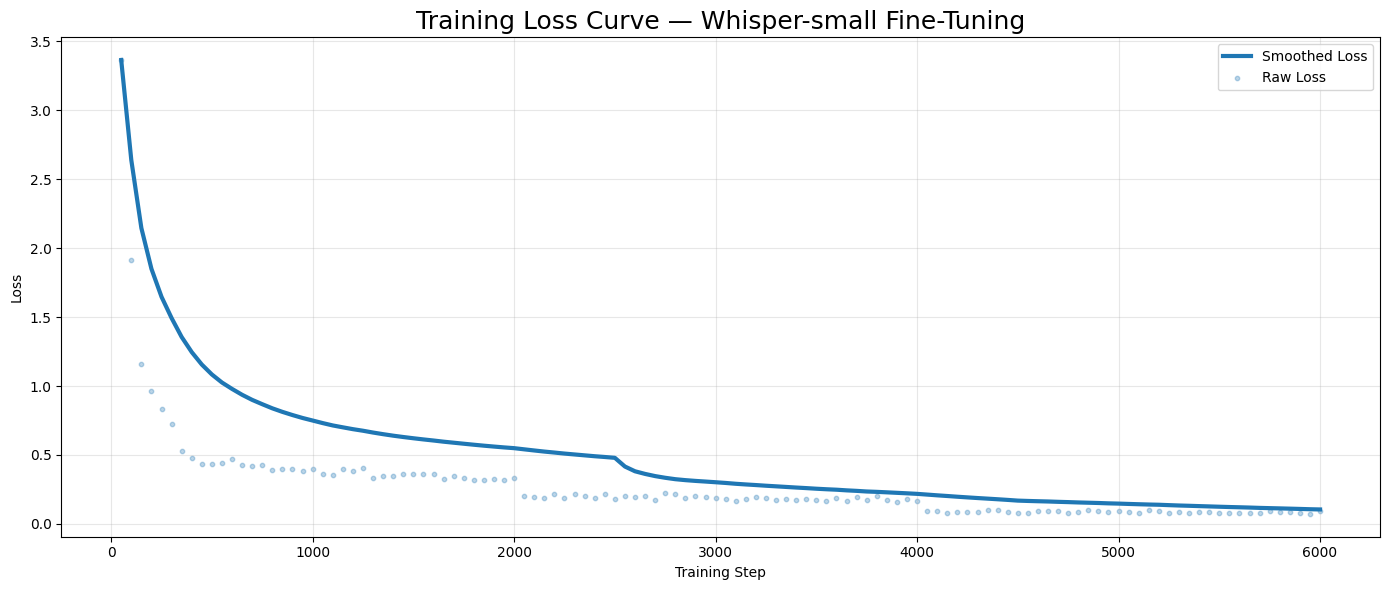

In [ ]:
# === CELL 19: Training Loss Curve ===

import json
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

CKPT = "/content/drive/MyDrive/WhisperProject/whisper_full_ft/checkpoint-6000"
state_path = Path(CKPT) / "trainer_state.json"

# Load trainer_state.json
with open(state_path, "r") as f:
    state = json.load(f)

df = pd.DataFrame(state["log_history"])

# Keep entries containing loss
df = df[df["loss"].notnull()]

# Smooth the loss curve
df["loss_smooth"] = df["loss"].rolling(window=50, min_periods=1).mean()

# Plot
plt.figure(figsize=(14,6))
plt.plot(df["step"], df["loss_smooth"], label="Smoothed Loss", linewidth=3)
plt.scatter(df["step"], df["loss"], s=10, alpha=0.3, label="Raw Loss")
plt.title("Training Loss Curve — Whisper-small Fine-Tuning", fontsize=18)
plt.xlabel("Training Step")
plt.ylabel("Loss")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
import torch
import evaluate
from tqdm import tqdm

wer_metric = evaluate.load("wer")
cer_metric = evaluate.load("cer")

base_model = WhisperForConditionalGeneration.from_pretrained("openai/whisper-small").to("cuda").eval()
base_processor = WhisperProcessor.from_pretrained(
    "openai/whisper-small", language="arabic", task="transcribe"
)

base_processor.tokenizer.pad_token = base_processor.tokenizer.eos_token
base_processor.tokenizer.pad_token_id = base_processor.tokenizer.eos_token_id
base_model.config.forced_decoder_ids = None
base_model.config.suppress_tokens = []

preds_base = []
refs_base = []

test_ds = raw["test"]

for ex in tqdm(test_ds):
    audio = ex["audio"]

    inp = base_processor.feature_extractor(
        audio["array"], sampling_rate=16000, return_tensors="pt"
    ).to("cuda")

    forced = base_processor.get_decoder_prompt_ids(language="arabic", task="transcribe")

    with torch.no_grad():
        ids = base_model.generate(
            inp["input_features"],
            forced_decoder_ids=forced,
            max_new_tokens=128,
        )

    preds_base.append(base_processor.batch_decode(ids, skip_special_tokens=True)[0])
    refs_base.append(ex["text"])

wer_base = wer_metric.compute(predictions=preds_base, references=refs_base)
cer_base = cer_metric.compute(predictions=preds_base, references=refs_base)

print("Base WER:", wer_base)
print("Base CER:", cer_base)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.
 68%|██████▊   | 5350/7872 [30:31<19:13,  2.19it/s]

In [ ]:
# === CELL 20: Base vs Fine-Tuned WER / CER ===

import matplotlib.pyplot as plt
import numpy as np

models = ["Base", "Fine-tuned"]
wer_vals = [wer_base * 100, wer * 100]
cer_vals = [cer_base * 100, cer * 100]

x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(7,5))
plt.bar(x - width/2, wer_vals, width, label="WER (%)")
plt.bar(x + width/2, cer_vals, width, label="CER (%)")

plt.xticks(x, models)
plt.ylabel("Error rate (%)")
plt.title("WER and CER: Base vs Fine-Tuned Whisper-small")
plt.grid(axis="y", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
# === CELL 21: WER/CER Across Checkpoints ===

import torch
import evaluate
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
from tqdm import tqdm
from transformers import WhisperForConditionalGeneration, WhisperProcessor

BASE_DIR = Path("/content/drive/MyDrive/WhisperProject/whisper_full_ft")
SPLIT = "test"
MAX_SAMPLES = 2000

wer_metric = evaluate.load("wer")
cer_metric = evaluate.load("cer")

checkpoints = sorted(
    [p for p in BASE_DIR.glob("checkpoint-*") if p.is_dir()],
    key=lambda p: int(p.name.split("-")[-1])
)

results = []

for epoch_idx, ckpt in enumerate(checkpoints, start=1):
    print(f"\nEvaluating {ckpt.name} (epoch ≈ {epoch_idx})")

    model = WhisperForConditionalGeneration.from_pretrained(ckpt).to("cuda").eval()
    processor = WhisperProcessor.from_pretrained(ckpt)

    processor.tokenizer.pad_token = processor.tokenizer.eos_token
    processor.tokenizer.pad_token_id = processor.tokenizer.eos_token_id
    model.config.forced_decoder_ids = None
    model.config.suppress_tokens = []

    preds, refs = [], []
    dataset = raw_datasets[SPLIT]

    for i, example in enumerate(tqdm(dataset)):
        if i >= MAX_SAMPLES:
            break

        audio = example["audio"]
        inputs = processor.feature_extractor(
            audio["array"],
            sampling_rate=audio["sampling_rate"],
            return_tensors="pt"
        ).to("cuda")

        with torch.no_grad():
            ids = model.generate(
                inputs["input_features"],
                max_new_tokens=128
            )

        preds.append(processor.batch_decode(ids, skip_special_tokens=True)[0])
        refs.append(example["text"])

    s_wer = wer_metric.compute(predictions=preds, references=refs) * 100
    s_cer = cer_metric.compute(predictions=preds, references=refs) * 100

    results.append({"epoch": epoch_idx, "wer": s_wer, "cer": s_cer})

df = pd.DataFrame(results)

# Plot
plt.figure(figsize=(8,5))
plt.plot(df["epoch"], df["wer"], marker="o", label="WER (%)")
plt.plot(df["epoch"], df["cer"], marker="s", label="CER (%)")
plt.xticks(df["epoch"])
plt.xlabel("Epoch (# of checkpoints)")
plt.ylabel("Error rate (%)")
plt.title("WER / CER Across Fine-Tuning Epochs")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

df


In [ ]:
# === CELL 22: LoRA vs Full Fine-Tuning Performance ===

import matplotlib.pyplot as plt
import numpy as np

models = ["Full FT", "LoRA"]
wer_values = [wer_full_ft * 100, wer_lora * 100]
cer_values = [cer_full_ft * 100, cer_lora * 100]

x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(7,5))
plt.bar(x - width/2, wer_values, width, label="WER (%)")
plt.bar(x + width/2, cer_values, width, label="CER (%)")

plt.xticks(x, models)
plt.ylabel("Error Rate (%)")
plt.title("LoRA vs Full Fine-Tuning — Whisper-small Arabic TTS")
plt.grid(axis="y", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()
